# **Moduel 4: Introduction to Aritificial Neural Networks and Deep Learning**

### **Prepared by: Dr. Hum Nath Bhandari, Department of Mathematics, RWU**

### **Course**: MATH 355/COMSC 415-Machine Learning

## **Case Study 3**: Building Classification Models Using DNN.



### Name:




### Overview

In this case sduty, you will build Deep Neural Networks to solve multi-class classification problems. Perform various model selection strategies to identify the best performing DNN  model configuration.


###  **Expected Learning Outcomes**:

- Understanding the given classification problem.

- Extracting and cleaning underlying datasets.

- Performing exploratory data analysis and visualization to understand the nature of target variable, input features, and relationships among the variales.

- Understanding the available classification techniques.

- Building and implementing Deep Neural Newotks for Classification.

- Hyperparameter Tuning and perforance evaluations.

- Implementing various strategies to improve the model performance.

- Identifying the best performing model for the given problem.






##  **Model: Deep Neural Networks(DNN) Classifier**



## **Problem (Multi-Class Classification):  Heart Disease Classification**


## **Data**

Download heart disease data set, called **Cleveland_Medical_Data2.csv**, from Bridges. Notice that it has the following 14 features in which one of them is the target variable.


### Features

- **age**: Age in years

- **sex**: Sex (1 = male; 0 = female)

- **cp**: Chest pain type (Value 1: typical angina; Value 2: atypical angina; Value 3: non-anginal pain, Value 4: asymptomatic)

- **trestbps**: Resting blood pressure (in mm Hg on admission to the hospital)

- **chol**: Serum cholestoral in mg/dl

- **fbs**: (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)

- **restecg**: Resting electrocardiographic results (Value 0: normal; Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria)

- **thalach**: Maximum heart rate achieved


- **exang**: Exercise induced angina (1 = yes; 0 = no)
- **oldpeak**: ST depression induced by exercise relative to rest
- **slope**: The slope of the peak exercise ST segment (Value 1: upsloping; Value 2: flat; Value 3: downsloping)
- **ca**: Number of major vessels (0-3) colored by flourosopy
- **thal**: 3 = normal; 6 = fixed defect; 7 = reversable defect


- **HeartDisease**: Diagnosis of heart disease:
   - value = 0 represents No Presence
   - value = 1, 2, 3, 4 represent Heart Disease Level 1, 2, 3, and 4 respectively.


   

## **Step 1: Data Extraction and Exploration**

Perform the following tasks.

- Load **Cleveland_Medical_Data2.csv** in your notebook and perform the following tasks.

- Perform basic exploration(**Hint**: you may use head(), info(), describe(), etc).

- Identify whether there are any missing values. Use appropriate strategies to handle missing values.

- Observe the relationships among variables (**Hint**: you may create joint plots, pairplots, heatmaps, etc)

- Make a list of top 5 features, called **top5_features**,  which show strong correlations (either positive or negative) with the target variable **HeartDisease**.


In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import random
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [89]:
data_path = "./data/" # make similar to this path

output_dir_path = "./results/" #make similar to this path




In [90]:

data = pd.read_csv(data_path+"Cleveland_Medical_Data.csv", na_values= '?')
data.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,HeartDisease
0,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
1,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
2,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
3,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
4,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0


In [91]:
#data.isnull().sum()

In [92]:
#data.dropna(axis=0, inplace=True)

#data.isnull().sum()

## **Step 2: Data Transformantion and Input Preparation**

At this point you have a some good understanding about the data set. Now, you will build machine learning models for **Multi-class Classification**. For this purpose.

- Split the data into features matrix **X_data** and the target vector as **y_data**. Use **head()** function to see the desired sets.

- Transform **X_data** using **StandardScaler** and save the data as **X_data_scaled**. Note, you don't need to transform y_data because it has only fininte integer lebels 0, 1, 2, 3, and 4

-  Further split **X_data_scaled** and **y_data**  where 75% of the data  goes to training sets (**X_train**, **y_train**) and 25% data goes to test sets (**X_test**, **y_test**).



In [93]:


column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'HeartDisease']


input_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']



X_data = data[input_features]
y_data = data['HeartDisease']



from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_data_scaled = scaler.fit_transform(X_data)


X_data_scaled =  pd.DataFrame(X_data_scaled, columns = input_features)

print(X_data_scaled.head())
print(y_data)



        age  sex        cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.791667  1.0  1.000000  0.622642  0.365297  0.0      1.0  0.282443    1.0   
1  0.791667  1.0  1.000000  0.245283  0.235160  0.0      1.0  0.442748    1.0   
2  0.166667  1.0  0.666667  0.339623  0.283105  0.0      0.0  0.885496    0.0   
3  0.250000  0.0  0.333333  0.339623  0.178082  0.0      1.0  0.770992    0.0   
4  0.562500  1.0  0.333333  0.245283  0.251142  0.0      0.0  0.816794    0.0   

    oldpeak  slope        ca  thal  
0  0.241935    0.5  1.000000   0.0  
1  0.419355    0.5  0.666667   1.0  
2  0.564516    1.0  0.000000   0.0  
3  0.225806    0.0  0.000000   0.0  
4  0.129032    0.0  0.000000   0.0  
0      2
1      1
2      0
3      0
4      0
      ..
297    1
298    2
299    3
300    1
301    0
Name: HeartDisease, Length: 302, dtype: int64


In [94]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data_scaled, y_data, test_size=0.25, random_state=20)

print("Training Sets:",  X_train.shape, y_train.shape)
print("Test Sets: ", X_test.shape, y_test.shape)


Training Sets: (226, 13) (226,)
Test Sets:  (76, 13) (76,)


## **Preprocessing target variable**

In [95]:

y_train = np.array(y_train)
y_test =  np.array(y_test)

print(y_train[0])
print(y_test[0])


4
3


**One-Hot Endoding for Target Variable**

In [96]:
from keras.utils import to_categorical

#Convert one-dimensional class arrays (output) into 5-dimensional class matrices:
y_train = to_categorical(y_train, 5)
y_test =  to_categorical(y_test, 5)
#to_categorical: Converts a class vector (integers) to multiple-classes matrix. It is called one-hot endoding
print(y_train[0])
print(y_test[0])

[0. 0. 0. 0. 1.]
[0. 0. 0. 1. 0.]


## **Step 3 Performance Evaluation Metrics**




In [97]:

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

import time as tm
def calculate_scores(y_true, y_pred):
  #accuracy score
  acc = accuracy_score(y_true,  y_pred)
  #precision score
  precision = precision_score(y_true, y_pred, average ="macro")
  #recall score,
  recall = recall_score(y_true, y_pred, average ="macro")
  #f1 score
  f1 = f1_score(y_true, y_pred, average ="macro")
  #confusion matrix
  cm = confusion_matrix(y_true,  y_pred)

  output_dictionary = {'acc': acc, 'precision':precision , 'recall': recall, "f1": f1, "cm":  cm}

  return (output_dictionary)


def confusion_matrix_plot(cm, fig_name):
  import seaborn as sns
  sns.set_theme(style = "whitegrid")
  plt.rc('font', weight='bold')
  fig = plt.figure(figsize=(6,5))
  sns.heatmap(cm, annot = True, fmt=".2f", linewidths=.5, square = False, cmap = "Greens_r", cbar = False)
  labels = ["No Heart Disease", "Heart Disease"]
  plt.xticks([0.5,1.5], labels, fontsize = 10 )
  plt.yticks([0.5, 1.5], labels, fontsize = 10)
  plt.ylabel('Actual labels');
  plt.title('Predicted labels');

  #all_sample_title = 'Accuracy Score(Logistic Regression)): {:.4f}'.format(score)
  #plt.title(" ", size = 10);
  fig.savefig(fig_name,dpi=600)
  #cbar_kws={"shrink": .5}
  plt.show()

def loss_plot(model_output):

  fig = plt.figure(figsize = (8,4))

  plt.plot(model_output.epoch, model_output.history['loss'], '--o', color = 'darkblue')

  plt.plot(model_output.epoch, model_output.history['val_loss'], '--o', color = 'olive')

  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss(MSE)")
  plt.legend(['Training loss', "Validation loss"],  loc= 'upper right')
  sns.set_style("whitegrid")
  fig.savefig(output_dir_path+ "train_valiation_loss_plot.png",dpi=600)



def loss_accuracy_plot(model_output):
  loss =  model_output.history['loss']
  val_loss = model_output.history['val_loss']
  accuracy =model_output.history['accuracy']
  val_acc = model_output.history['val_accuracy']

  #epochs = np.arange(len(loss))

  epochs = model_output.epoch
  fig = plt.figure(figsize = (12,5))

  plt.subplot(121)
  plt.plot(epochs, loss, color = 'red', marker = "s")
  plt.plot(epochs, val_loss, marker = "^")
  plt.legend(["loss", "validation loss"], loc="best")
  plt.xlabel("epoch")
  plt.ylabel("loss")
  plt.title("Training and Validation Loss")

  plt.subplot(122)
  plt.plot(epochs, accuracy, color = 'red', marker = "o")
  plt.plot(epochs, val_acc, marker = "*")
  plt.legend(["accuracy", "validation accuracy"], loc="best")
  plt.xlabel("epoch")
  plt.ylabel("accuracy")
  plt.title("Training and Validation Accuracy Scores")
  fig.savefig(output_dir_path + "error_acuracy_plot.png", dpi = 600)
  plt.show()


def write_dic_to_file(dic_name, file_name):
  file = open(file_name, 'w')
  file.write(str(dic_name))
  file.close()

import ast
def read_dic_from_file(file_name):
  file = open(file_name, "r")
  contents = file.read()
  dictionary = ast.literal_eval(contents)
  file.close()
  return dictionary



## **Step 4: Building and Implementing DNN Classifier**



We will be writing the following functionalities.

1. **DNN_Classifier()**: Write a function which can build generic DNN model for classification.

2. **Loss_Plot():** Write a function to visualize training error vs epochs.

3. **DNN_Hyperparameter_Tuning()**: Write a function which can be used for hyperparameter tuning of the models.

4. **DNN_Classifier_Implementation()**: Write a function which helps to train the model in a full scale with optimized hyperparameters.

5. **Multiple_DNN_Classifiers()**: Write a function which helps to implement multiple DNN classifiers

6. **Results_Visualization()**: Write a function which performs results visualization.

7. **Statistical_Analysis()**:Write a function which perform statistical analysis.


## **Import Libraries for Building Models**

In [98]:

import tensorflow as tf
from keras import  Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras import optimizers
import time
import math


## **Build DNN Classifier**

In [99]:


def DNN_Classifier(layers, input_features, output_dim, optimizer = 'Adam', learning_rate = 0.001, verbose = 1):

  #Initialize sequential modeling architecture
  model = Sequential()

  #Add hidden layers and neurons
  for i in range(len(layers)):
    if len(layers)==1:
      model.add(Dense(layers[i], input_dim = input_features,  activation='relu'))
      model.add(Dropout(0.10))
    else:
        if i == 0:
          model.add(Dense(layers[i], input_dim = input_features,  activation='relu'))
        else:
          model.add(Dense(layers[i], activation='relu'))

        model.add(Dropout(0.10))

  #Add output layers
  model.add(Dense(output_dim, activation = 'softmax')) # Neurons = 5, because we have five classes

  #Select optimizers and learning rates
  if optimizer == 'Adam':
    opt = optimizers.Adam(learning_rate = learning_rate)
  elif optimizer == 'Adagrad':
    opt = optimizers.Adagrad(learning_rate = learning_rate)
  elif optimizer == 'Nadam':
    opt = optimizers.Nadam(learning_rate = learning_rate)
  elif optimizer == 'Adadelta':
    opt = optimizers.Adadelta(learning_rate= learning_rate)
  elif optimizer == 'RMSprop':
    opt = optimizers.RMSprop(learning_rate= learning_rate)
  else:
    print("No optimizer found in the list(['Adam', 'Adagrad','Nadam', 'Adadelta', 'RMSprop'])! Please apply your optimizer manually...")

  #model.build(input_shape= (num_features,batch_size))

  #Compile the model
  model.compile(loss='categorical_crossentropy', optimizer = opt,  metrics = ['accuracy'])

  if verbose == 1:
    print(model.summary())
  return model



In [100]:

input_features = 13
output_dim = 5

optimizers_names = ['Adam', 'Adagrad', 'Nadam']

learning_rate = 0.001
verbose = 1
layers = [10, 5, 5]


dnn_model1  = DNN_Classifier(layers, input_features, output_dim, optimizer =  optimizers_names[0], learning_rate= learning_rate, verbose = verbose)
dnn_model1



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 10)             │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 5)              │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255 (1020.00 B)

 Trainable params: 255 (1020.00 B)

 Non-trainable params: 0 (0.00 B)

None


<Sequential name=sequential_4, built=True>

## **Fit the DNN_Classifier()**

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 10)             │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 5)              │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255 (1020.00 B)

 Trainable params: 255 (1020.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4379 - loss: 1.6083 - val_accuracy: 0.5614 - val_loss: 1.5995
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5266 - loss: 1.5958 - val_accuracy: 0.5614 - val_loss: 1.5890
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5266 - loss: 1.5867 - val_accuracy: 0.5614 - val_loss: 1.5781
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5266 - loss: 1.5772 - val_accuracy: 0.5614 - val_loss: 1.5683
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5266 - loss: 1.5685 - val_accuracy: 0.5614 - val_loss: 1.5575
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5266 - loss: 1.5550 - val_accuracy: 0.5614 - val_loss: 1.5465
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5266 - loss: 1.5470 - val_accuracy: 0.5614 - val_loss: 1.5345
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5266 - loss: 1.5382 - val_accuracy: 0.56

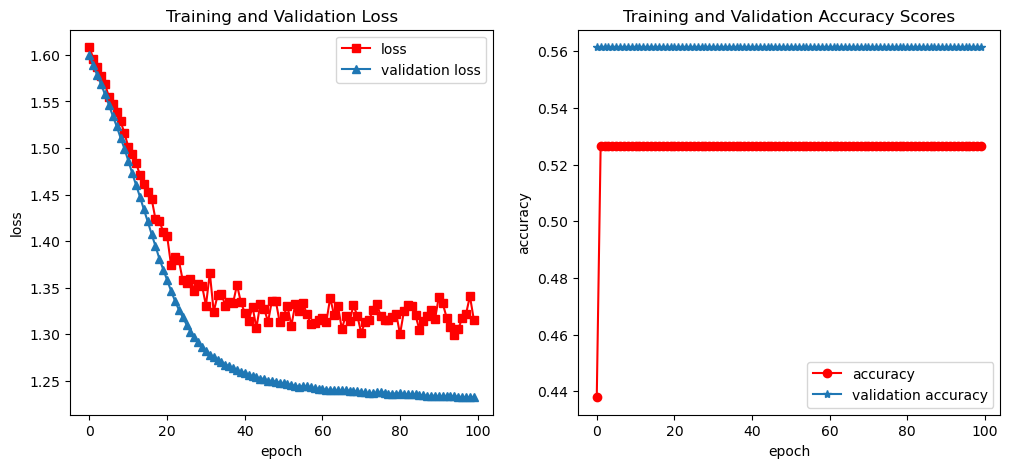

In [101]:

input_features = 13
output_dim = 5

optimizers_names = ['Adam', 'Adagrad', 'Nadam']

learning_rate = 0.001
verbose = 1
layers = [10, 5, 5]

batch_size =  16
verbose = 1
epochs =  100


dnn_model1  = DNN_Classifier(layers, input_features, output_dim, optimizer =  optimizers_names[0], learning_rate= learning_rate, verbose = verbose)
dnn_model1

model_output1  = dnn_model1.fit(X_train, y_train, epochs= epochs, batch_size = batch_size, validation_split = 0.25, verbose = verbose)
loss_accuracy_plot(model_output1)


## **Models Construction**

Architectures 1: Single Hidden Layer DNN Models

- Model 1: 10-DNN
- Model 2: 20-DNN
- Model 3: 50-DNN
- Model 4: 100 DNN
- Model 5: 200 DNN


Architectures 2: Multiple Hidden Layers DNN Models
- Model 6: 10-5 DNN
- Model 7: 20-10 DNN
- Model 8: 50-20 DNN
- Model 9: 100-50 DNN
- Model 10: 200-100 DNN

## **Hyperparameter Tuning**

One of the important task for any machine learning project is tuning the hyperparameters of the constructed models. In DNN, important  hyperparameters are the following.

1. Epochs
2. Optimizer
3. Learning rate
4. Bach_size


Epoch can be tuned by using the above loss_accuracy_plot. We can observe the behavior of training and validation acccuracy to understand the early stoping epoch. That particular epoch will be the best epoch to stop the training and considered as hyperparmeter.


You can combine these hyperparameters in a list:

hyperparameters = [optimizer, epochs, learning rates, batch_sizes]




In [102]:
"""
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=20)

print("Training Sets:",  X_train.shape, y_train.shape)
print("Test Sets: ", X_val.shape, y_val.shape)

"""

'\nX_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=20)\n\nprint("Training Sets:",  X_train.shape, y_train.shape)\nprint("Test Sets: ", X_val.shape, y_val.shape)\n\n'

In [103]:

def  DNN_Hyperparameter_Tuning(
              layers,
               input_features,
               output_dim,
               optimizers_names,
               learning_rates,
               batch_sizes,
               epochs,
               X_train,
               y_train,
               X_val,
               y_val,
               num_replicates,
               verbose):

  best_avg_acc = 0.00

  #Best hyperparameters will be selected based on the performance

  all_avg_acc = np.zeros((len(optimizers_names), len(learning_rates), len(batch_sizes)))

  all_avg_loss = np.zeros((len(optimizers_names), len(learning_rates), len(batch_sizes)))

  all_avg_elapsed_time = np.zeros((len(optimizers_names), len(learning_rates), len(batch_sizes)))



  best_hyper_parameters = {"model": layers,  "optimizer": None, "learning_rate": None, "batch_size": None,"best_avg_acc": None}

  #hist_csv_file = 'model_history'+ str(time.time())+'.csv'
 # you can try to record elapsed time.
  for opt in range(len(optimizers_names)):

    for lr in range(len(learning_rates)):

      for batch_size in range(len(batch_sizes)):

        collect_acc = []
        collect_loss = []
        collect_time = []

        for i in range(num_replicates):

          print("\n=========Running for ===" + optimizers_names[opt] + " optimizer " + str(learning_rates[lr]) +  " learning_rate " +  str(batch_sizes[batch_size]) + " batch_size and " + str(i) +  " replicate " +  "\n")
          model = DNN_Classifier(layers, input_features, output_dim, optimizer =  optimizers_names[opt], learning_rate = learning_rates[lr], verbose = verbose)

          start = time.time()
          callback = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience= 5)

          history = model.fit(X_train, y_train, batch_size = batch_sizes[batch_size], epochs = epochs, validation_data = (X_val, y_val), callbacks = [callback], verbose = verbose)
          end = time.time()
          collect_time.append(end - start)

          #hist_df = pd.DataFrame(history.history)
          #hist_df.to_csv("history")
          #with open("hist_csv_file.csv", mode='w') as f:
          #  hist_df.to_csv(f)

          #Calculating scores
          #Calculating test scores
          scores = model.evaluate(X_val, y_val, verbose = 0)

          collect_loss.append(scores[0]) # first value is loss
          collect_acc.append(scores[1]) # second acc

          #end of the innermost loop

        avg_loss = np.mean(np.array(collect_loss))

        all_avg_loss[opt][lr][batch_size] = avg_loss

        avg_acc = np.mean(np.array(collect_acc))

        all_avg_acc[opt][lr][batch_size] = avg_acc

        avg_time = np.mean(np.array(collect_time))

        all_avg_elapsed_time[opt][lr][batch_size] = avg_time

        if avg_acc > best_avg_acc:
          best_avg_acc = avg_acc
          best_hyper_parameters = {"model": str(layers),  "optimizer": optimizers_names[opt], "learning_rate": learning_rates[lr], "batch_size": batch_sizes[batch_size], "best_avg_acc": best_avg_acc}


  output_dictionary = {
      "best_hyper_parameters":  best_hyper_parameters,
      "all_avg_acc": all_avg_acc,
      "all_avg_loss": all_avg_loss,
      "all_avg_elapsed_time": all_avg_elapsed_time

       }

  #writing output dictionary in the file

  file_name = output_dir_path+ "dnn-" + str(layers) + "hyperparameter_tuning__results" + ".txt"
  write_dic_to_file(output_dictionary, file_name)

  print("Best_hyper_parameters(DNN) \n", output_dictionary['best_hyper_parameters'])
  print("all_avg_acc: \n", output_dictionary['all_avg_acc'])
  print("all_avg_loss: \n", output_dictionary['all_avg_loss'])
  print( "all_avg_elapsed_time: \n", all_avg_elapsed_time)

  return output_dictionary['best_hyper_parameters']


### **Model 1: 10-DNN Hyperparameter Tuning**

In [104]:

output_dir_path = "./results/Hyperparameter_Tuning_Results/" #make similar to this path

model1_best_hyperparameters = DNN_Hyperparameter_Tuning(
               layers = [10, 5],
               input_features = 13,
               output_dim = 5,
               optimizers_names =["Adam", "Adagrad", "Adadelta"],
               learning_rates = [0.1, 0.01, 0.001],
               batch_sizes = [8, 16, 32],
               epochs = 40,
               X_train = X_train,
               y_train = y_train,
               X_val = X_val,
               y_val = y_val,
               num_replicates =5,
               verbose =1)


model1_best_hyperparameters


NameError: name 'X_val' is not defined

## **Model 2: 20-DNN Hyperparameter Tuning**

## **Model 3: 50-DNN Hyperparameter Tuning**

## **Model 4: 100-DNN Hyperparameter Tuning**

## **Model 5: 200-DNN Hyperparameter Tuning**

## **Model 6: 10-5-DNN Hyperparameter Tuning**

## **Model 7: 20-10-DNN Hyperparameter Tuning**

## **Model 8: 50-20-DNN Hyperparameter Tuning**

## **Model 9: 100-50-DNN Hyperparameter Tuning**

## **Model 10: 200-100-DNN Hyperparameter Tuning**

## **List of Models with Best Hyperparameters**

In [105]:

models  = [[10], [20],  [50], [100], [200], [10, 5], [20, 10], [50, 20],  [100, 50], [200, 100]]


best_hyper_parameters   = [
                            ['Adagrad', 0.001, 8], #Model 1: 10-DNN
                             ['Adagrad', 0.001, 8], #Model 2: 20-DNN
                             ['Adagrad', 0.001, 8], #Model 3: 50-DNN
                            ['Adagrad', 0.001, 8], #Model 4: 100-DNN
                            ['Adagrad', 0.001, 8], #Model 5: 200-DNN
                            ['Adagrad', 0.001, 8], #Model 6: 10-5-DNN
                            ['Adagrad', 0.001, 8], #Model 7: 20-10-DNN
                            ['Adagrad', 0.001, 8], #Model 8: 50-20-DNN
                            ['Adagrad', 0.001, 8], #Model 9: 100-50-DNN
                            ['Adagrad', 0.001, 8], #Model 10: 200-100-DNN
                        ]



# **DNN Classifier Implementation**

to be completed..

In [106]:

def  DNN_Classifier_Implimentation(
               layers,
               input_features,
               output_dim,
               hyper_parameters = ['Adam', 0.01, 8], #list of hyperparameters
               X_train = None,
               y_train = None,
               X_test =  None,
               y_test =  None,
               epochs = 2,
               num_replicates = 2,
               verbose = 1):

  #============ arrays for collecting test scores ================#

  y_train_original = np.argmax(y_train, axis = 1) #converting into 1D array form of lables
  y_test_original  = np.argmax(y_test, axis = 1) # converting into 1D array form of the labels

  model_history = []
  train_predictions = []
  test_predictions = []


  #============ arrays for collecting test scores ================#
  acc_array = np.zeros(num_replicates)
  precision_array = np.zeros(num_replicates)
  recall_array    = np.zeros(num_replicates)
  f1_array = np.zeros(num_replicates)
  elapsed_time_array = np.zeros(num_replicates)
  cm = []


  for i in range(num_replicates):
    print("Program is running for %d replicate ----->\n" %i)
    print('.........................Building DNN Model.......................\n')

    #Build DNN model
    model = DNN_Classifier(layers, input_features, output_dim, optimizer =  hyper_parameters[0], learning_rate= hyper_parameters[1], verbose = verbose)

    print('.........................Fitting  DNN Model.......................\n')
    start = time.time()
    callback = tf.keras.callbacks.EarlyStopping(monitor = 'loss', patience= 5)
    history = model.fit(X_train, y_train, batch_size = hyper_parameters[2], epochs = epochs, callbacks = [callback], verbose = verbose)
    end = time.time()


    #Save model history
    model_history.append(history)

    print('....................Calculating predictions...................\n')

    train_pred = np.argmax(model.predict(X_train), axis = 1)
    test_pred = np.argmax(model.predict(X_test), axis = 1)

    train_predictions.append(train_pred)
    test_predictions.append(test_pred)


    #============== Calculating performance scores=========
    scores =   calculate_scores(y_test_original, test_pred)

    acc_array[i] = scores['acc']
    precision_array[i] = scores['precision']
    recall_array[i]    = scores['recall']
    f1_array[i] =  scores['f1']
    elapsed_time_array[i] =  end - start
    cm.append(scores['cm'])

  #====Collecting results from the best performing replicate
  best_index = acc_array.argmax() # best replicate

  best_acc = acc_array[best_index]
  precision_with_best_acc = precision_array[best_index]
  recall_with_best_acc = recall_array[best_index]
  f1_with_best_acc = f1_array[best_index]
  cm_with_best_acc =  cm[best_index]

  elapsed_time_with_best_acc = elapsed_time_array[best_index]
  train_predictions_with_best_acc = train_predictions[best_index]
  test_predictions_with_best_acc = test_predictions[best_index]
  loss_with_best_acc = model_history[best_index].history['loss']


  #Collecting important results========
  performance_metrics =  {

        'avg_scores': {'acc': np.mean(acc_array), 'precision': np.mean(precision_array), 'recall': np.mean(recall_array), 'f1': np.mean(f1_array),  'elapsed_time': np.mean(elapsed_time_array)},
        'minimums': {'acc': np.min(acc_array), 'precision': np.min(precision_array), 'recall': np.min(recall_array), 'f1': np.min(f1_array),  'elapsed_time': np.min(elapsed_time_array)},

        'maximums': {'acc': np.max(acc_array), 'precision': np.max(precision_array), 'recall': np.max(recall_array), 'f1': np.max(f1_array),  'elapsed_time': np.max(elapsed_time_array)},

        'std': {'acc': np.std(acc_array), 'precision': np.std(precision_array), 'recall': np.std(recall_array), 'f1': np.std(f1_array),  'elapsed_time': np.std(elapsed_time_array)},

        'avg_scores': {'acc': np.mean(acc_array), 'precision': np.mean(precision_array), 'recall': np.mean(recall_array), 'f1': np.mean(f1_array),  'elapsed_time': np.mean(elapsed_time_array)},

        'scores': {'acc': acc_array, 'precision': precision_array, 'recall': recall_array, 'f1': f1_array, 'cm': cm, 'elapsed_time': elapsed_time_array}

                  }

  model_with_best_acc = {
                            'replicate': best_index,
                            'acc': best_acc,
                            'precision': precision_with_best_acc,
                            'recall':  recall_with_best_acc,
                            'elapsed_time': elapsed_time_with_best_acc,
                            'f1': f1_with_best_acc,
                            'cm':  cm_with_best_acc,
                            'train_predictions':train_predictions_with_best_acc,
                            'test_predictions': test_predictions_with_best_acc,
                            'y_train':y_train_original,
                            'y_test': y_test_original,
                            'loss':loss_with_best_acc,

                             #'val_loss': val_loss_with_best_rmse
                            }

  #======= Collecting hyperparameters=============#
  hyper_parameters = {'conv_layers': layers,
                        'model_specific_hyper_parameters': hyper_parameters,#additional best_hyper_parmeters for each models
                       'epochs': epochs,
                       'num_replicates': num_replicates,
                       #'test_split':test_split
                        }


  output_dictionary = {'hyper_parameters': hyper_parameters,
                        'performance_metrics': performance_metrics,
                         'best_model': model_with_best_acc
                       }


  #Save all scores in a file for statistical study
  #pd.DataFrame(performance_metrics['scores']['acc']).to_csv(output_dir_path+'dnn_'+ str(layers)+'_acc.csv')
  #pd.DataFrame(performance_metrics['scores']['precision']).to_csv(output_dir_path+'dnn_'+ str(layers)+ '_precision.csv')
  #pd.DataFrame(performance_metrics['scores']['recall']).to_csv(output_dir_path + 'dnn_'+ str(layers) + '_recall.csv')
  #pd.DataFrame(performance_metrics['scores']['f1_score']).to_csv(output_dir_path +'dnn_'+ str(layers)+'_f1_score.csv')

  #Save data sets
  #pd.DataFrame(y_train_original).to_csv(output_dir_path+'y_train.csv')
  #pd.DataFrame(y_test_original).to_csv(output_dir_path+'y_test.csv')

  #Save best model results

  #pd.DataFrame(model_with_best_acc['train_predictions']).to_csv(output_dir_path+'best_dnn_'+ str(layers) + str(_best_index)+ '_replicate'+ '_train_predictions.csv')
  #pd.DataFrame(model_with_best_acc['test_predictions']).to_csv(output_dir_path+ 'best_dnn_'+ str(layers) + str(_best_index)+ '_replicate'+ '_test_predictions.csv')
  #pd.DataFrame(model_with_best_acc['loss']).to_csv(output_dir_path+'best_dnn_'+ str(layers) + str(_best_index)+ '_replicate'+  '_loss.csv')


  #writing all statistics
  #write_dic_to_file(performance_metrics,  output_dir_path+'dnn_'+ str(layers)+ '_performance_metrics.csv')

  #writing entire output dictionary in the file
  #file_name =  output_dir_path+'dnn_'+ str(layers)+'full_results.txt'
  #write_dic_to_file(output_dictionary, file_name)

  print("Progress: All works are done successfully, congratulations!!\n")

  return output_dictionary



##

In [107]:

def Multiple_DNN_Classifiers(
               model_configurations,
               hyper_parameters,
               input_features,
               output_dim,
               X_train = None,
               y_train = None,
               X_test =  None,
               y_test =  None,
               epochs = 2,
               num_replicates = 2,
               verbose = 1):

  num_models = len(model_configurations)

  #== to collect all scores===#
  acc = []
  precision = []
  recall = []
  f1 = []
  cm = []
  elapsed_time = []

  #===to collect all avg scores===#
  avg_acc = []
  avg_precision = []
  avg_recall = []
  avg_f1 = []
  #avg_confusion_matrix = []
  avg_elapsed_time = []

  #=== to iteratively update the best accuracy and the corresponding model
  best_acc = 0
  best_avg_acc = 0
  best_model_configuration = None
  best_model_output = None

  for i in range(num_models):

    print("Running model with layers neurons: \n", model_configurations[i])


    print("Best Hyper_parameters used: \n", hyper_parameters[i])


    output = DNN_Classifier_Implimentation(
                layers  = model_configurations[i],
                input_features = input_features,
                output_dim = output_dim,
                hyper_parameters =  hyper_parameters[i],
                X_train = X_train,
                y_train = y_train,
                X_test =  X_test,
                y_test = y_test,
                epochs = epochs,
                num_replicates = num_replicates,
                verbose = verbose)

    acc.append(output['performance_metrics']['scores']['acc'])
    precision.append(output['performance_metrics']['scores']['precision'])
    recall.append(output['performance_metrics']['scores']['recall'])
    f1.append(output['performance_metrics']['scores']['f1'])
    cm.append(output['performance_metrics']['scores']['cm'])
    elapsed_time.append(output['performance_metrics']['scores']['elapsed_time'])


    avg_acc.append(output['performance_metrics']['avg_scores']['acc'])
    avg_precision.append(output['performance_metrics']['avg_scores']['precision'])
    avg_recall.append(output['performance_metrics']['avg_scores']['recall'])
    avg_f1.append(output['performance_metrics']['avg_scores']['f1'])
    #avg_confusion_matrix.append(output['performance_metrics']['avg_scores']['confusion_matrix'])
    avg_elapsed_time.append(output['performance_metrics']['avg_scores']['elapsed_time'])

    if avg_acc[i] > best_avg_acc:
      best_avg_acc = avg_acc[i]
      best_acc = output['best_model']['acc']
      best_model_configuration = model_configurations[i]
      best_model_output = output


  acc = np.array(acc)
  precision = np.array(precision)
  recall = np.array(recall)
  f1 = np.array(f1)
  elapsed_time = np.array(elapsed_time)


  # ===== Collecting all  scores================================#
  performance_metrics = {

      'scores':  {'model_configurations': model_configurations,
                    'acc': acc,
                    'precision': precision,
                    'recall': recall,
                    'f1': f1,
                    #'cm': cm,
                    'elapsed_time': elapsed_time
                   },

       'avg_scores':  pd.DataFrame({'model_configurations': model_configurations,
                                     'acc': np.array(avg_acc),
                                     'precision': np.array(avg_precision),
                                     'f1': np.array(avg_f1),
                                     'recall':np.array(avg_recall),
                                     'elapsed_time':np.array(avg_elapsed_time)}),

       'stds':   pd.DataFrame({ 'model_configurations': model_configurations,
                                  'acc': np.std(acc, axis = 1),
                                  'precision': np.std(precision, axis = 1),
                                   'recall': np.std(recall, axis = 1),
                                   'f1': np.std(f1, axis = 1),
                                   'elapsed_time': np.std(elapsed_time, axis = 1)
                                   }),

       'minimums':   pd.DataFrame({ 'model_configurations': model_configurations,
                                  'acc': np.min(acc, axis = 1),
                                  'precision': np.min(precision, axis = 1),
                                   'recall': np.min(recall, axis = 1),
                                   'f1': np.min(f1, axis = 1),
                                   'elapsed_time': np.min(elapsed_time, axis = 1)
                                   }),


         'maximums':   pd.DataFrame({ 'model_configurations': model_configurations,
                                  'acc': np.max(acc, axis = 1),
                                  'precision': np.max(precision, axis = 1),
                                   'recall': np.max(recall, axis = 1),
                                   'f1': np.max(f1, axis = 1),
                                   'elapsed_time': np.max(elapsed_time, axis = 1)
                                   }),
        }


  output_dictionary = {
                      'hyper_parameters': hyper_parameters,
                      'best_avg_acc': best_avg_acc,
                      'best_acc': best_acc,
                      'best_model_configuration': best_model_configuration,
                      'best_model_output': best_model_output
                      }

  #Save all statistics:
  performance_metrics['avg_scores'].to_csv(output_dir_path+'multiple_dnn_models_average_scores.csv')
  performance_metrics['stds'].to_csv(output_dir_path+'multiple_dnn_models_stds.csv')
  performance_metrics['minimums'].to_csv(output_dir_path+'multiple_dnn_models_minimums.csv')
  performance_metrics['maximums'].to_csv(output_dir_path+'multiple_dnn_models_maximums.csv')


  #Save all scores in the file for future analysis
  pd.DataFrame(performance_metrics['scores']['acc']).to_csv(output_dir_path+'multiple_dnn_models_all_acc.csv')
  pd.DataFrame(performance_metrics['scores']['precision']).to_csv(output_dir_path+'multiple_dnn_models_all_precision.csv')
  pd.DataFrame(performance_metrics['scores']['recall']).to_csv(output_dir_path+'multiple_dnn_models_all_recall.csv')
  pd.DataFrame(performance_metrics['scores']['f1']).to_csv(output_dir_path+'multiple_dnn_models_all_f1_score.csv')

  #Save best model results
  pd.DataFrame(best_model_output['best_model']['loss']).to_csv(output_dir_path+'best_dnn_model_loss.csv')
  pd.DataFrame(best_model_output['best_model']['train_predictions']).to_csv(output_dir_path+'best_dnn_model_train_predictions.csv')
  pd.DataFrame(best_model_output['best_model']['test_predictions']).to_csv(output_dir_path+'best_dnn_model_test_predictions.csv')
  pd.DataFrame(best_model_output['best_model']['cm']).to_csv(output_dir_path+'best_dnn_model_confusion_matrix.csv')
  pd.DataFrame(best_model_output['performance_metrics']['scores']['acc']).to_csv(output_dir_path+'best_dnn_model_all_acc.csv')
  #pd.DataFrame(best_model_output['performance_metrics']['scores']['precision']).to_csv(output_dir_path+'best_dnn_model_precision.csv')
  #pd.DataFrame(best_model_output['performance_metrics']['scores']['recall']).to_csv(output_dir_path+'best_dnn_model_recall.csv')
  #pd.DataFrame(best_model_output['performance_metrics']['scores']['f1_score']).to_csv(output_dir_path+'best_dnn_model_all_f1_score.csv')


  #Save data sets
  y_train_original = np.argmax(y_train, axis = 1) #converting into 1D array form of lables
  y_test_original  = np.argmax(y_train, axis = 1) # converting into 1D array form of the labels
  pd.DataFrame(y_train_original).to_csv(output_dir_path+'y_train.csv')
  pd.DataFrame(y_test_original).to_csv(output_dir_path+'y_test.csv')

  #writing all result in the file
  write_dic_to_file(output_dictionary, output_dir_path + "multiple_dnn_models_full_results.txt")

  #Display some key results in the screen
  print("\nBest model and its avg accuracy):\n", best_model_configuration, best_avg_acc, best_acc)
  print("Hyper_parameters:\n", hyper_parameters)
  print('\nAverage scores:\n',  performance_metrics['avg_scores'])
  print('\nStandard_deviations:\n',  performance_metrics['stds'])
  print('\nMinimums:\n',  performance_metrics['minimums'])
  print('\nMaximums:\n',  performance_metrics['maximums'])
  print("Progress: All works are done successfully, congratulations!!\n")



## **Step 1: Running Single Layer DNN Models**

In [ ]:
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data_scaled, y_data, test_size=0.20, random_state=20)

print("Training Sets:",  X_train.shape, y_train.shape)
print("Test Sets: ", X_test.shape, y_test.shape)

"""

'\nfrom sklearn.model_selection import train_test_split\n\nX_train, X_test, y_train, y_test = train_test_split(X_data_scaled, y_data, test_size=0.20, random_state=20)\n\nprint("Training Sets:",  X_train.shape, y_train.shape)\nprint("Test Sets: ", X_test.shape, y_test.shape)\n\n'

In [ ]:
"""
y_train = np.array(y_train)
y_test =  np.array(y_test)

print(y_train[0])
print(y_test[0])

from keras.utils import to_categorical

#Convert one-dimensional class arrays (output) into 5-dimensional class matrices:
y_train = to_categorical(y_train, 5)
y_test =  to_categorical(y_test, 5)
#to_categorical: Converts a class vector (integers) to binary class matrix.
print(y_train[0])
print(y_test[0])

"""

'\ny_train = np.array(y_train)\ny_test =  np.array(y_test)\n\nprint(y_train[0])\nprint(y_test[0])\n\nfrom keras.utils import to_categorical\n\n#Convert one-dimensional class arrays (output) into 5-dimensional class matrices:\ny_train = to_categorical(y_train, 5)\ny_test =  to_categorical(y_test, 5)\n#to_categorical: Converts a class vector (integers) to binary class matrix.\nprint(y_train[0])\nprint(y_test[0])\n\n'

In [ ]:

#model_configurations  = [[10], [20],  [50], [100], [200]]
#len(model_configurations)

In [ ]:
"""
model_configurations  = [[10], [20],  [50], [100], [200]]

#model_configurations  = [[10, 5], [20, 10], [50, 20],  [100, 50], [200, 100]]


best_hyper_parameters   = [
                             ['Adagrad', 0.001, 8], #Model 1: 10-DNN
                             ['Adagrad', 0.001, 8], #Model 2: 20-DNN
                             ['Adagrad', 0.001, 8], #Model 3: 50-DNN
                            ['Adagrad', 0.001, 8], #Model 4: 100-DNN
                            ['Adagrad', 0.1, 8] #Model 5: 200-DNN
                           #['Adagrad', 0.1, 8], #Model 6: 10-5-DNN
                           #['Adagrad', 0.1, 8], #Model 7: 20-10-DNN
                           #['Adagrad', 0.1, 8], #Model 8: 50-20-DNN
                           #['Adagrad', 0.1, 8], #Model 9: 100-50-DNN
                            #['Adagrad', 0.1, 8], #Model 10: 200-100-DNN
                        ]

output_dir_path =  "/content/drive/MyDrive/MATH355-COMSC415-Machine-Learning/Results/Case_Study3_Results/Single_DNN_Layers/"


Multiple_DNN_Classifiers(
               model_configurations = model_configurations,
               hyper_parameters = best_hyper_parameters,
               input_features = 13,
               output_dim = 5,
               X_train = X_train,
               y_train = y_train,
               X_test =  X_test,
               y_test =  y_test,
               epochs = 10,
               num_replicates = 10,
               verbose = 1)
"""

'\nmodel_configurations  = [[10], [20],  [50], [100], [200]]\n\n#model_configurations  = [[10, 5], [20, 10], [50, 20],  [100, 50], [200, 100]]\n\n\nbest_hyper_parameters   = [\n                             [\'Adagrad\', 0.001, 8], #Model 1: 10-DNN\n                             [\'Adagrad\', 0.001, 8], #Model 2: 20-DNN\n                             [\'Adagrad\', 0.001, 8], #Model 3: 50-DNN\n                            [\'Adagrad\', 0.001, 8], #Model 4: 100-DNN\n                            [\'Adagrad\', 0.1, 8] #Model 5: 200-DNN\n                           #[\'Adagrad\', 0.1, 8], #Model 6: 10-5-DNN\n                           #[\'Adagrad\', 0.1, 8], #Model 7: 20-10-DNN\n                           #[\'Adagrad\', 0.1, 8], #Model 8: 50-20-DNN\n                           #[\'Adagrad\', 0.1, 8], #Model 9: 100-50-DNN\n                            #[\'Adagrad\', 0.1, 8], #Model 10: 200-100-DNN\n                        ]\n\noutput_dir_path =  "/content/drive/MyDrive/MATH355-COMSC415-Machine-Learn

## **Step 2: Running Multi-Layer DNN Models**

In [ ]:
"""
#model_configurations  = [[10], [20],  [50], [100], [200]]

model_configurations  = [[10, 5], [20, 10], [50, 20],  [100, 50], [200, 100]]


best_hyper_parameters   = [
                             #['Adagrad', 0.001, 8], #Model 1: 10-DNN
                             #['Adagrad', 0.001, 8], #Model 2: 20-DNN
                             #['Adagrad', 0.001, 8], #Model 3: 50-DNN
                            #['Adagrad', 0.001, 8], #Model 4: 100-DNN
                            #['Adagrad', 0.1, 8] #Model 5: 200-DNN
                           ['Adagrad', 0.01, 8], #Model 6: 10-5-DNN
                           ['Adagrad', 0.01, 8], #Model 7: 20-10-DNN
                           ['Adagrad', 0.01, 8], #Model 8: 50-20-DNN
                           ['Adagrad', 0.01, 8], #Model 9: 100-50-DNN
                            ['Adagrad', 0.01, 8] #Model 10: 200-100-DNN
                        ]

output_dir_path =  "/content/drive/MyDrive/MATH355-COMSC415-Machine-Learning/Results/Case_Study3_Results/Multiple_DNN_Layers/"


Multiple_DNN_Classifiers(
               model_configurations = model_configurations,
               hyper_parameters = best_hyper_parameters,
               input_features = 13,
               output_dim = 5,
               X_train = X_train,
               y_train = y_train,
               X_test =  X_test,
               y_test =  y_test,
               epochs = 10,
               num_replicates = 10,
               verbose = 1)

"""

'\n#model_configurations  = [[10], [20],  [50], [100], [200]]\n\nmodel_configurations  = [[10, 5], [20, 10], [50, 20],  [100, 50], [200, 100]]\n\n\nbest_hyper_parameters   = [\n                             #[\'Adagrad\', 0.001, 8], #Model 1: 10-DNN\n                             #[\'Adagrad\', 0.001, 8], #Model 2: 20-DNN\n                             #[\'Adagrad\', 0.001, 8], #Model 3: 50-DNN\n                            #[\'Adagrad\', 0.001, 8], #Model 4: 100-DNN\n                            #[\'Adagrad\', 0.1, 8] #Model 5: 200-DNN\n                           [\'Adagrad\', 0.01, 8], #Model 6: 10-5-DNN\n                           [\'Adagrad\', 0.01, 8], #Model 7: 20-10-DNN\n                           [\'Adagrad\', 0.01, 8], #Model 8: 50-20-DNN\n                           [\'Adagrad\', 0.01, 8], #Model 9: 100-50-DNN\n                            [\'Adagrad\', 0.01, 8] #Model 10: 200-100-DNN\n                        ]\n\noutput_dir_path =  "/content/drive/MyDrive/MATH355-COMSC415-Machine-L

# **Result Visualization**

/content/drive/MyDrive/Machine_Learning/Results

## **Plot 1: Loss plot of the best Single and Multi Layer DNN**

In [ ]:
"""
import seaborn as sns
sns.set_theme(style="whitegrid")

def loss_plot(loss1, loss2, fig_name):

  fig = plt.figure(figsize = (6,4))

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 1
  plt.rc('xtick',labelsize=12)
  plt.rc('ytick',labelsize=12)
  plt.rcParams["axes.labelweight"] = "bold"

  colors = ['purple', 'mediumblue']

  plt.plot(loss1 , '--o',  linewidth = 2.5, color = colors[0])
  plt.plot(loss2, '--o',  linewidth = 2.5, color = colors[1])
  #plt.plot(cnn_loss, '--o',  linewidth = 1.5, color = colors[2])

  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend(['Single DNN Layer', 'Multi_DNN Layer'],  loc = 'upper right')
  #plt.rcParams['axes.facecolor']='w'
  plt.grid(color='#F5F5DC')

  fig.savefig(fig_name,dpi=600)

  """

'\nimport seaborn as sns\nsns.set_theme(style="whitegrid")\n\ndef loss_plot(loss1, loss2, fig_name):\n\n  fig = plt.figure(figsize = (6,4))\n\n  plt.rcParams["axes.edgecolor"] = "0.15"\n  plt.rcParams["axes.linewidth"]  = 1\n  plt.rc(\'xtick\',labelsize=12)\n  plt.rc(\'ytick\',labelsize=12)\n  plt.rcParams["axes.labelweight"] = "bold"\n\n  colors = [\'purple\', \'mediumblue\']\n\n  plt.plot(loss1 , \'--o\',  linewidth = 2.5, color = colors[0])\n  plt.plot(loss2, \'--o\',  linewidth = 2.5, color = colors[1])\n  #plt.plot(cnn_loss, \'--o\',  linewidth = 1.5, color = colors[2])\n\n  plt.xlabel("Epochs")\n  plt.ylabel("Loss")\n  plt.legend([\'Single DNN Layer\', \'Multi_DNN Layer\'],  loc = \'upper right\')\n  #plt.rcParams[\'axes.facecolor\']=\'w\'\n  plt.grid(color=\'#F5F5DC\')\n\n  fig.savefig(fig_name,dpi=600)\n\n  '

## Setting up the Paths

In [ ]:
path1 =  "./results/Single_DNN_Layers/"

path2 =  "./results/Multiple_DNN_Layers/"

output_dir_path = "./results/"

In [ ]:
"""

best_loss1 = pd.read_csv(path1+'best_dnn_model_loss.csv')
best_loss2 = pd.read_csv(path2+'best_dnn_model_loss.csv')


loss_plot(best_loss1.iloc[:, 1], best_loss2.iloc[:, 1], output_dir_path +"loss_plot.png")

"""

'\n\nbest_loss1 = pd.read_csv(path1+\'best_dnn_model_loss.csv\')\nbest_loss2 = pd.read_csv(path2+\'best_dnn_model_loss.csv\')\n\n\nloss_plot(best_loss1.iloc[:, 1], best_loss2.iloc[:, 1], output_dir_path +"loss_plot.png")\n\n'

##  **Plot 2: Average Scores Plot**

In [ ]:
"""
def avg_test_scores_plot(configuration1, configuration2, avg_scores1, avg_scores2, fig_name):
  sns.set_theme(style = "whitegrid")
  plt.rc('font', weight='bold')

  fig = plt.figure(figsize = (16, 5)) #(22,5)

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 1
  plt.rc('xtick',labelsize=12)
  plt.rc('ytick',labelsize=12)
  plt.rcParams["axes.labelweight"] = "bold"

  plt.subplot(121)
  plt.plot(avg_scores1['model_configurations'], avg_scores1['acc'], '-o', linewidth = 2.5, color = 'y')
  plt.plot(avg_scores1['model_configurations'], avg_scores1['precision'], '-o', linewidth = 2.5, color = 'c')
  plt.plot(avg_scores1['model_configurations'], avg_scores1['recall'], '-o', linewidth = 2.5, color = 'red')
  plt.plot(avg_scores1['model_configurations'], avg_scores1['f1'], '-o', linewidth = 2.5, color = 'darkblue')
  plt.xticks([0, 1,2,3,4],configuration1, fontsize = 8,  rotation=30)
  #plt.title("Accuracy")
  plt.title("Single Layer DNN Model Configurations", fontsize = 10)
  plt.ylabel("Performance scores", fontsize = 10)
  plt.legend(['Accuracy', 'Precision' , 'Recall', 'f1 Score'],  loc = 'best')

  plt.subplot(122)
  plt.plot(avg_scores2['model_configurations'], avg_scores2['acc'], '-o', linewidth = 2.5, color = 'y')
  plt.plot(avg_scores2['model_configurations'], avg_scores2['precision'], '-o', linewidth = 2.5, color = 'c')
  plt.plot(avg_scores2['model_configurations'], avg_scores2['recall'], '-o', linewidth = 2.5, color = 'red')
  plt.plot(avg_scores2['model_configurations'], avg_scores2['f1'], '-o', linewidth = 2.5, color = 'darkblue')
  plt.xticks([0, 1,2,3,4], configuration2, fontsize = 8,  rotation=30)
  #plt.title("Accuracy")
  plt.title("Multi Layers DNN Model Configurations", fontsize = 10)
  plt.ylabel("Performance scores", fontsize = 10)
  plt.legend(['Accuracy', 'Precision' , 'Recall', 'f1 Score'],  loc = 'best')

  fig.savefig(fig_name,dpi=600)
  plt.show()

  """

'\ndef avg_test_scores_plot(configuration1, configuration2, avg_scores1, avg_scores2, fig_name):\n  sns.set_theme(style = "whitegrid")\n  plt.rc(\'font\', weight=\'bold\')\n\n  fig = plt.figure(figsize = (16, 5)) #(22,5)\n\n  plt.rcParams["axes.edgecolor"] = "0.15"\n  plt.rcParams["axes.linewidth"]  = 1\n  plt.rc(\'xtick\',labelsize=12)\n  plt.rc(\'ytick\',labelsize=12)\n  plt.rcParams["axes.labelweight"] = "bold"\n\n  plt.subplot(121)\n  plt.plot(avg_scores1[\'model_configurations\'], avg_scores1[\'acc\'], \'-o\', linewidth = 2.5, color = \'y\')\n  plt.plot(avg_scores1[\'model_configurations\'], avg_scores1[\'precision\'], \'-o\', linewidth = 2.5, color = \'c\')\n  plt.plot(avg_scores1[\'model_configurations\'], avg_scores1[\'recall\'], \'-o\', linewidth = 2.5, color = \'red\')\n  plt.plot(avg_scores1[\'model_configurations\'], avg_scores1[\'f1\'], \'-o\', linewidth = 2.5, color = \'darkblue\')\n  plt.xticks([0, 1,2,3,4],configuration1, fontsize = 8,  rotation=30)\n  #plt.title("Accur

In [ ]:

"""
avg_scores1 = pd.read_csv(path1+'multiple_dnn_models_average_scores.csv')
avg_scores2 = pd.read_csv(path2+'multiple_dnn_models_average_scores.csv')

single_dnn_configurations = ['M1:10-DNN', 'M2:20-DNN', 'M3:50-DNN', 'M4:100-DNN', 'M5:200-DNN']
multi_dnn_configurations = ['M6:10-5-DNN', 'M7:20-10-DNN', 'M8:50-20-DNN', 'M9:100-50-DNN', 'M10:200-100-DNN']

avg_test_scores_plot(single_dnn_configurations, multi_dnn_configurations, avg_scores1, avg_scores2, output_dir_path+ "multiple_avg_scores_plots.png")

"""

'\navg_scores1 = pd.read_csv(path1+\'multiple_dnn_models_average_scores.csv\')\navg_scores2 = pd.read_csv(path2+\'multiple_dnn_models_average_scores.csv\')\n\nsingle_dnn_configurations = [\'M1:10-DNN\', \'M2:20-DNN\', \'M3:50-DNN\', \'M4:100-DNN\', \'M5:200-DNN\']\nmulti_dnn_configurations = [\'M6:10-5-DNN\', \'M7:20-10-DNN\', \'M8:50-20-DNN\', \'M9:100-50-DNN\', \'M10:200-100-DNN\']\n\navg_test_scores_plot(single_dnn_configurations, multi_dnn_configurations, avg_scores1, avg_scores2, output_dir_path+ "multiple_avg_scores_plots.png")\n\n'

## **Plot 3: All score boxplots**

In [ ]:
"""
def all_scores_boxplot(config, acc, precision, recall, f1, fig_name):

  sns.set_theme(style = "whitegrid")
  plt.rc('font', weight='bold')

  fig = plt.figure(figsize = (16,8))

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 1
  plt.rc('xtick',labelsize=12)
  plt.rc('ytick',labelsize=12)
  plt.rcParams["axes.labelweight"] = "bold"

  plt.subplot(221)
  p1 = plt.boxplot(acc, patch_artist=True)
  for i, box in enumerate(p1['boxes']):
    # change outline color
    box.set(color= 'blue', linewidth = 1.2)
    # change fill color
    box.set(facecolor = 'cyan')
  plt.xticks([])
  #plt.xticks([1,2,3,4,5], config,fontsize = 8, rotation = 30 )
  plt.title('', fontweight='bold')
 # plt.xlabel('Number of Single Conv Filters')
  plt.ylabel('Accuracy')


  plt.subplot(222)
  p2 = plt.boxplot(precision, patch_artist=True)
  for i, box in enumerate(p2['boxes']):
    # change outline color
    box.set(color= 'blue', linewidth = 1.2)
    # change fill color
    box.set(facecolor = 'slateblue')
  plt.xticks([])
  #plt.xticks([1,2,3,4,5], config, fontsize = 8, rotation = 30 )
  plt.title('', fontweight='bold')
  #plt.xlabel('Number of Single Conv Filters')
  plt.ylabel('Precision')


  plt.subplot(223)
  p3 = plt.boxplot(recall, patch_artist=True)
  for i, box in enumerate(p3['boxes']):
    # change outline color
    box.set(color= 'blue', linewidth = 1.2)
    # change fill color
    box.set(facecolor = 'violet')
  plt.xticks([ 1,2,3,4,5], config,fontsize = 8, rotation = 30 )
  plt.title('', fontweight='bold')
  #plt.xlabel('Number of Single Conv Filters')
  plt.ylabel('Recall')

  plt.subplot(224)
  p4 = plt.boxplot(f1, patch_artist=True)
  for i, box in enumerate(p4['boxes']):
    # change outline color
    box.set(color= 'blue', linewidth = 1.2)
    # change fill color
    box.set(facecolor = 'y')
  plt.xticks([1,2,3,4,5], config,fontsize = 8, rotation = 30 )
  plt.title('', fontweight='bold')
  #plt.xlabel('Number of Single Conv Filters')
  plt.ylabel('f1 score')

  fig.savefig(fig_name, dpi=600)
  plt.show()

  """


'\ndef all_scores_boxplot(config, acc, precision, recall, f1, fig_name):\n\n  sns.set_theme(style = "whitegrid")\n  plt.rc(\'font\', weight=\'bold\')\n\n  fig = plt.figure(figsize = (16,8))\n\n  plt.rcParams["axes.edgecolor"] = "0.15"\n  plt.rcParams["axes.linewidth"]  = 1\n  plt.rc(\'xtick\',labelsize=12)\n  plt.rc(\'ytick\',labelsize=12)\n  plt.rcParams["axes.labelweight"] = "bold"\n\n  plt.subplot(221)\n  p1 = plt.boxplot(acc, patch_artist=True)\n  for i, box in enumerate(p1[\'boxes\']):\n    # change outline color\n    box.set(color= \'blue\', linewidth = 1.2)\n    # change fill color\n    box.set(facecolor = \'cyan\')\n  plt.xticks([])\n  #plt.xticks([1,2,3,4,5], config,fontsize = 8, rotation = 30 )\n  plt.title(\'\', fontweight=\'bold\')\n # plt.xlabel(\'Number of Single Conv Filters\')\n  plt.ylabel(\'Accuracy\')\n\n\n  plt.subplot(222)\n  p2 = plt.boxplot(precision, patch_artist=True)\n  for i, box in enumerate(p2[\'boxes\']):\n    # change outline color\n    box.set(color= \'b

In [ ]:
# Read all scores files
"""

single_dnn_acc = pd.read_csv(path1+'multiple_dnn_models_all_acc.csv')
single_dnn_precision = pd.read_csv(path1+'multiple_dnn_models_all_precision.csv')
single_dnn_recall = pd.read_csv(path1+'multiple_dnn_models_all_recall.csv')
single_dnn_f1= pd.read_csv(path1+'multiple_dnn_models_all_f1_score.csv')



multi_dnn_acc = pd.read_csv(path2+'multiple_dnn_models_all_acc.csv')
multi_dnn_precision = pd.read_csv(path2+'multiple_dnn_models_all_precision.csv')
multi_dnn_recall = pd.read_csv(path2+'multiple_dnn_models_all_recall.csv')
multi_dnn_f1= pd.read_csv(path2+'multiple_dnn_models_all_f1_score.csv')


single_dnn_configurations = ['M1:10-DNN', 'M2:20-DNN', 'M3:50-DNN', 'M4:100-DNN', 'M5:200-CNN']
multi_dnn_configurations = ['M6:10-5-DNN', 'M7:20-10-DNN', 'M8:50-20-DNN', 'M9:100-50-DNN', 'M10:200-100-DNN']

all_scores_boxplot(single_dnn_configurations, single_dnn_acc.iloc[:, 1:].T, single_dnn_precision.iloc[:, 1:].T,  single_dnn_recall.iloc[:, 1:].T,
                       single_dnn_f1.iloc[:, 1:].T, output_dir_path+ "single_dnn_all_scores_boxplots.png")


all_scores_boxplot(multi_dnn_configurations , multi_dnn_acc.iloc[:, 1:].T, multi_dnn_precision.iloc[:, 1:].T,  multi_dnn_recall.iloc[:, 1:].T,
                      multi_dnn_f1.iloc[:, 1:].T, output_dir_path+ "multi_dnn_all_scores_boxplots.png")



"""

'\n\nsingle_dnn_acc = pd.read_csv(path1+\'multiple_dnn_models_all_acc.csv\')\nsingle_dnn_precision = pd.read_csv(path1+\'multiple_dnn_models_all_precision.csv\')\nsingle_dnn_recall = pd.read_csv(path1+\'multiple_dnn_models_all_recall.csv\')\nsingle_dnn_f1= pd.read_csv(path1+\'multiple_dnn_models_all_f1_score.csv\')\n\n\n\nmulti_dnn_acc = pd.read_csv(path2+\'multiple_dnn_models_all_acc.csv\')\nmulti_dnn_precision = pd.read_csv(path2+\'multiple_dnn_models_all_precision.csv\')\nmulti_dnn_recall = pd.read_csv(path2+\'multiple_dnn_models_all_recall.csv\')\nmulti_dnn_f1= pd.read_csv(path2+\'multiple_dnn_models_all_f1_score.csv\')\n\n\nsingle_dnn_configurations = [\'M1:10-DNN\', \'M2:20-DNN\', \'M3:50-DNN\', \'M4:100-DNN\', \'M5:200-CNN\']\nmulti_dnn_configurations = [\'M6:10-5-DNN\', \'M7:20-10-DNN\', \'M8:50-20-DNN\', \'M9:100-50-DNN\', \'M10:200-100-DNN\']\n\nall_scores_boxplot(single_dnn_configurations, single_dnn_acc.iloc[:, 1:].T, single_dnn_precision.iloc[:, 1:].T,  single_dnn_recall.i

## **Plot 4: Visualizing Best model Confusion Matrix**

In [ ]:
"""

def confusion_matrix_plot(cm, fig_name):
  import seaborn as sns
  sns.set_theme(style = "whitegrid")
  plt.rc('font', weight='bold')
  fig = plt.figure(figsize=(8,7))
  sns.heatmap(cm, annot = True, fmt=".2f", linewidths=.5, square = False, cmap = "Greens_r", cbar = False)

  labels = ["No Heart Disease", "Lavel 1", "Lavel 2", "Lavel 3", "Lavel 4"]

  plt.xticks([0.5,1.5, 2.5,3.5, 4.5], labels, fontsize = 10 )
  plt.yticks([0.5,1.5, 2.5,3.5, 4.5], labels, fontsize = 10)
  plt.ylabel('Actual labels');
  plt.title('Predicted labels');

  #all_sample_title = 'Accuracy Score(Logistic Regression)): {:.4f}'.format(score)
  #plt.title(" ", size = 10);
  fig.savefig(fig_name,dpi=600)
  #cbar_kws={"shrink": .5}
  plt.show()
  """



'\n\ndef confusion_matrix_plot(cm, fig_name):\n  import seaborn as sns\n  sns.set_theme(style = "whitegrid")\n  plt.rc(\'font\', weight=\'bold\')\n  fig = plt.figure(figsize=(8,7))\n  sns.heatmap(cm, annot = True, fmt=".2f", linewidths=.5, square = False, cmap = "Greens_r", cbar = False)\n\n  labels = ["No Heart Disease", "Lavel 1", "Lavel 2", "Lavel 3", "Lavel 4"]\n\n  plt.xticks([0.5,1.5, 2.5,3.5, 4.5], labels, fontsize = 10 )\n  plt.yticks([0.5,1.5, 2.5,3.5, 4.5], labels, fontsize = 10)\n  plt.ylabel(\'Actual labels\');\n  plt.title(\'Predicted labels\');\n\n  #all_sample_title = \'Accuracy Score(Logistic Regression)): {:.4f}\'.format(score)\n  #plt.title(" ", size = 10);\n  fig.savefig(fig_name,dpi=600)\n  #cbar_kws={"shrink": .5}\n  plt.show()\n  '

In [ ]:
"""

best_single_layer_dnn_cm = pd.read_csv(path1+ 'best_dnn_model_confusion_matrix.csv')
best_multi_layers_dnn_cm = pd.read_csv(path2+ 'best_dnn_model_confusion_matrix.csv')

confusion_matrix_plot(best_single_layer_dnn_cm .iloc[:,1:] , output_dir_path+ 'best_single_layer_dnn_cm.png')

confusion_matrix_plot(best_multi_layers_dnn_cm.iloc[:,1:], output_dir_path+ 'best_multi_layer_dnn_cm.png')

"""


"\n\nbest_single_layer_dnn_cm = pd.read_csv(path1+ 'best_dnn_model_confusion_matrix.csv')\nbest_multi_layers_dnn_cm = pd.read_csv(path2+ 'best_dnn_model_confusion_matrix.csv')\n\nconfusion_matrix_plot(best_single_layer_dnn_cm .iloc[:,1:] , output_dir_path+ 'best_single_layer_dnn_cm.png')\n\nconfusion_matrix_plot(best_multi_layers_dnn_cm.iloc[:,1:], output_dir_path+ 'best_multi_layer_dnn_cm.png')\n\n"

## **Plot 5:  Performing Statistical Analysis**

In [ ]:
"""

def comparative_qq_plots(data1, data2, fig_name):
  fig = plt.figure(figsize = (12,5))

  plt.rcParams["axes.edgecolor"] = "0.15"
  plt.rcParams["axes.linewidth"]  = 1
  plt.rc('xtick',labelsize=12)
  plt.rc('ytick',labelsize=12)
  plt.rcParams["axes.labelweight"] = "bold"


  ax1= fig.add_subplot(121)
  scipy.stats.probplot(data1, dist=scipy.stats.norm, sparams=(0,1), plot=ax1)
  ax1.get_lines()[0].set_marker('o')
  ax1.get_lines()[0].set_markerfacecolor('mediumblue')
  ax1.get_lines()[0].set_markersize(8.0)
  ax1.get_lines()[1].set_linewidth(3.0)
  plt.title("Single Layer DNN", fontweight='bold')


  ax2= fig.add_subplot(122)
  scipy.stats.probplot(data2, dist=scipy.stats.norm, sparams=(0,1), plot=ax2)
  ax2.get_lines()[0].set_marker('o')
  ax2.get_lines()[0].set_markerfacecolor('mediumblue')
  ax2.get_lines()[0].set_markersize(8.0)
  ax2.get_lines()[1].set_linewidth(3.0)
  plt.title("Multi Layers DNN ", fontweight='bold')

  fig.savefig(fig_name,dpi=600)
  plt.show()



import scipy

def perform_normality_test(sample1, sample2):
  print("Performaing Normality Tests\n")
  print("Single_layer_dnn_acc: ")
  print(scipy.stats.normaltest(sample1))
  print("multi_layers_dnn_acc:")
  print(scipy.stats.normaltest(sample2))

def perform_pairwise_ttests(sample1, sample2):
  print("\n Two-sample ttest between sample 1 and sample 2")
  print(scipy.stats.ttest_ind(sample1, sample2, equal_var = False))  # It does not require variences to be equal.

  """


'\n\ndef comparative_qq_plots(data1, data2, fig_name):\n  fig = plt.figure(figsize = (12,5))\n\n  plt.rcParams["axes.edgecolor"] = "0.15"\n  plt.rcParams["axes.linewidth"]  = 1\n  plt.rc(\'xtick\',labelsize=12)\n  plt.rc(\'ytick\',labelsize=12)\n  plt.rcParams["axes.labelweight"] = "bold"\n\n\n  ax1= fig.add_subplot(121)\n  scipy.stats.probplot(data1, dist=scipy.stats.norm, sparams=(0,1), plot=ax1)\n  ax1.get_lines()[0].set_marker(\'o\')\n  ax1.get_lines()[0].set_markerfacecolor(\'mediumblue\')\n  ax1.get_lines()[0].set_markersize(8.0)\n  ax1.get_lines()[1].set_linewidth(3.0)\n  plt.title("Single Layer DNN", fontweight=\'bold\')\n\n\n  ax2= fig.add_subplot(122)\n  scipy.stats.probplot(data2, dist=scipy.stats.norm, sparams=(0,1), plot=ax2)\n  ax2.get_lines()[0].set_marker(\'o\')\n  ax2.get_lines()[0].set_markerfacecolor(\'mediumblue\')\n  ax2.get_lines()[0].set_markersize(8.0)\n  ax2.get_lines()[1].set_linewidth(3.0)\n  plt.title("Multi Layers DNN ", fontweight=\'bold\')\n\n  fig.savefi

In [ ]:

"""

best_single_layer_dnn_acc = pd.read_csv(path1+ 'best_dnn_model_all_acc.csv')
best_multi_layers_dnn_acc = pd.read_csv(path2+ 'best_dnn_model_all_acc.csv')

"""


"\n\nbest_single_layer_dnn_acc = pd.read_csv(path1+ 'best_dnn_model_all_acc.csv')\nbest_multi_layers_dnn_acc = pd.read_csv(path2+ 'best_dnn_model_all_acc.csv')\n\n"

In [ ]:
"""
fig_name = output_dir_path+ "best_model_rmse_qq_plots.png"


print("===========Visualizing qq plots ======================\n")
comparative_qq_plots(best_single_layer_dnn_acc.iloc[:,1],best_multi_layers_dnn_acc .iloc[:,1], fig_name)


print("===========Performing Normality Ttest:======================\n")
perform_normality_test(best_single_layer_dnn_acc.iloc[:,1],best_multi_layers_dnn_acc .iloc[:,1])

print("===========Performing Ttest:======================\n")
perform_pairwise_ttests(best_single_layer_dnn_acc.iloc[:,1],best_multi_layers_dnn_acc .iloc[:,1])
"""

'\nfig_name = output_dir_path+ "best_model_rmse_qq_plots.png"\n\n\nprint("===========Visualizing qq plots ======================\n")\ncomparative_qq_plots(best_single_layer_dnn_acc.iloc[:,1],best_multi_layers_dnn_acc .iloc[:,1], fig_name)\n\n\nprint("===========Performing Normality Ttest:======================\n")\nperform_normality_test(best_single_layer_dnn_acc.iloc[:,1],best_multi_layers_dnn_acc .iloc[:,1])\n\nprint("===========Performing Ttest:======================\n")\nperform_pairwise_ttests(best_single_layer_dnn_acc.iloc[:,1],best_multi_layers_dnn_acc .iloc[:,1])\n'

# **Best Model Performance in Test Data**

In [ ]:

"""
test_pred = pd.read_csv(path2+ 'best_dnn_model_test_predictions.csv') # it is just the assumption
y_test = pd.read_csv(path2+ 'y_test.csv')

#print(np.array(test_pred.iloc[:,1]))
#print(np.array(y_test.iloc[:,1]))


print(np.array(test_pred[:20]))
print(np.array(y_test[:20]))

"""

"\ntest_pred = pd.read_csv(path2+ 'best_dnn_model_test_predictions.csv') # it is just the assumption\ny_test = pd.read_csv(path2+ 'y_test.csv')\n\n#print(np.array(test_pred.iloc[:,1]))\n#print(np.array(y_test.iloc[:,1]))\n\n\nprint(np.array(test_pred[:20]))\nprint(np.array(y_test[:20]))\n\n"